# Adjudication Impact Deep Dive

Notebook 11 (`11_affinity_diagnostisc_metrics_pipeline.ipynb`) showed the headline effect of LLM
adjudication: what fraction of judged pairs moved closer to or further from the expert label. This
notebook picks up from that last section and looks at the individual cases behind those numbers.

For every `(Abstract_Index, RA2025_ID)` pair sent to the judge (`Final_Method == "adjudicated_llm"`),
we compare:
- `prejudge_level` — the bucket implied by the raw cross-model mean score (`Affinity_Mean`)
- `pred_level` — the bucket implied by the judge's final score (`Final_Affinity`)
- `expert_level` — the ground-truth bucket from the expert calibration set

Two dataframes are built:
1. `improved_df` — pairs where the judge moved the label from wrong to correct
2. `worsened_df` — pairs where the judge moved the label from correct to wrong

Each row is enriched with the abstract text, the RA question, every individual model's raw score
and reasoning, and the judge's own `Final_Reason`, so specific cases can be read end-to-end.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.dpi"] = 120

## Load expert labels, adjudicated predictions, per-model votes, and abstract text

In [ ]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

expert_root = repo_root / "data" / "results" / "affinity_calibration"
pred_root = repo_root / "data" / "results" / "affinity_benchmark"

expert_run_dir = "20260728_abstracts_evaluation_template_mark_om_v1"
# pred_run_dir = "20260726_134607_1"
pred_run_dir = "20260726_134607_4"

expert_label_col = "Evaluator_Affinity_Level"
pred_score_col = "Final_Affinity"

LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}


def normalize_level(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        text = value.strip().lower()
        return text.capitalize() if text in {"low", "moderate", "high"} else np.nan
    score = float(value)
    if 0 <= score < 40:
        return "Low"
    if 40 <= score <= 80:
        return "Moderate"
    if 80 <= score < 120:
        return "High"
    return np.nan

In [ ]:
expert_df = pd.read_csv(expert_root / expert_run_dir / "calibration_abstract_question_affinities.csv")
pred_df = pd.read_csv(pred_root / pred_run_dir / "adjudicated_ra_affinities.csv")
model_rows_df = pd.read_csv(pred_root / pred_run_dir / "adjudicated_ra_model_rows.csv")
abstract_lookup_df = pd.read_csv(pred_root / pred_run_dir / "abstract_lookup_cleaned.csv")

print("Expert rows:", len(expert_df))
print("Pred rows:", len(pred_df))
print("Model-vote rows:", len(model_rows_df))
print("Abstracts with cleaned text:", len(abstract_lookup_df))

Expert rows: 602
Pred rows: 5040
Model-vote rows: 25131
Abstracts with cleaned text: 105


## Build the pre- vs post-judge comparison (same logic as notebook 11)

In [ ]:
# expert_df and pred_df both carry 'Document Title' / 'RA_Question'; keep pred_df's copies only.
expert_cols = ["Abstract_Index", "RA2025_ID", expert_label_col]
merged_df = pd.merge(expert_df[expert_cols], pred_df, on=["Abstract_Index", "RA2025_ID"], how="inner")
merged_df["expert_level"] = merged_df[expert_label_col].apply(normalize_level)
merged_df["prejudge_level"] = merged_df["Affinity_Mean"].apply(normalize_level)
merged_df["pred_level"] = merged_df[pred_score_col].apply(normalize_level)

clean_df = merged_df.dropna(subset=["expert_level", "prejudge_level", "pred_level"]).copy()
for col in ["expert_level", "prejudge_level", "pred_level"]:
    clean_df[col.replace("_level", "_num")] = clean_df[col].map(LABEL_TO_NUM)

# Only pairs actually sent to the LLM judge: ensemble_mean pairs have prejudge == pred by
# construction and would just show up as "unchanged", adding no information here.
adjudicated_df = clean_df[clean_df["Final_Method"] == "adjudicated_llm"].copy()

adjudicated_df["prejudge_matches_expert"] = adjudicated_df["prejudge_num"] == adjudicated_df["expert_num"]
adjudicated_df["pred_matches_expert"] = adjudicated_df["pred_num"] == adjudicated_df["expert_num"]
adjudicated_df["judge_helped"] = (
    adjudicated_df["pred_matches_expert"].astype(int) - adjudicated_df["prejudge_matches_expert"].astype(int)
)
adjudicated_df["shift_size"] = (adjudicated_df["pred_num"] - adjudicated_df["prejudge_num"]).abs()

print("Judged pairs:", len(adjudicated_df))
print(adjudicated_df["judge_helped"].map({1: "improved", 0: "unchanged", -1: "worsened"}).value_counts())

Judged pairs: 406
judge_helped
unchanged    380
worsened      16
improved      10
Name: count, dtype: int64


## Enrich each judged pair with abstract text, RA question, and per-model votes

`adjudicated_ra_affinities.csv` already carries `Document Title` and `RA_Question`. We add:
- `Abstract_Cleaned` — the cleaned abstract text, from `abstract_lookup_cleaned.csv`
- one `score__<model_slug>` column per benchmarked model, from `adjudicated_ra_model_rows.csv`,
  showing what each model scored the pair before the judge saw it

In [ ]:
model_votes_df = model_rows_df.pivot_table(
    index=["Abstract_Index", "RA2025_ID"],
    columns="Model_Slug",
    values="LLM_Affinity",
    aggfunc="first",
).add_prefix("score__")

enriched_df = (
    adjudicated_df
    .merge(abstract_lookup_df[["Abstract_Index", "Abstract_Cleaned"]], on="Abstract_Index", how="left")
    .merge(model_votes_df, on=["Abstract_Index", "RA2025_ID"], how="left")
)

enriched_df.shape

(406, 37)

## 1) Cases where adjudication improved the classification

Pairs where the pre-judge bucket disagreed with the expert but the judge's final bucket matched it.

In [ ]:
summary_cols = [
    "Abstract_Index", "RA2025_ID", "Document Title", "RA_Question",
    "expert_level", "prejudge_level", "pred_level",
    "Affinity_Mean", "Affinity_Std", "Affinity_Range", "agreement_mean", "shift_size",
]

improved_df = (
    enriched_df[enriched_df["judge_helped"] > 0]
    .sort_values("shift_size", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(improved_df)} pairs improved by adjudication")
display(improved_df[summary_cols].head(20))

10 pairs improved by adjudication


,Abstract_Index,RA2025_ID,Document Title,RA_Question,expert_level,prejudge_level,pred_level,Affinity_Mean,Affinity_Std,Affinity_Range,agreement_mean,shift_size
0,10.1109/TPWRS.2022.3224971,36,A Two-Stage Power Distribution Scheme of Multiple Wind Farms Participating in Primary Frequency Regulation,what system services can be designed to enable response from ibrs that can be a substitute for inertia (i.e. very fast frequency response),High,Moderate,High,76.2,15.880806,36.0,0.500000,1
1,10.1109/TPWRS.2024.3408844,13,DER-Inverter Based Reactive Power Ancillary Service for Supporting Peer-to-Peer Transactive Energy Trading in Distribution Networks,"how can system operators quantify the bulk-level energy and service opportunities from der, and how can these services be shared among distribution operators, bulk operators, aggregators and (wher...",Moderate,High,Moderate,80.4,17.271364,40.0,0.500000,1
2,10.1109/TPWRS.2024.3510924,33,Resilient Distributed Control for Power Systems With Multiple Synchronous Generators and DERs Satisfying Capability Curve Requirements,how should the definitions of services for ibr-dominated grids be structured and can standard services and standard characteristics be defined as reasonable for large and small ibrs and across var...,Low,Moderate,Low,41.6,14.240786,38.0,0.500000,1
3,10.1109/TPWRS.2023.3273195,47,A Scalable Approach to Large Scale Risk-Averse Distribution Grid Expansion Planning,"how do system operators adequately account for the overall system impact of extreme events in planning studies, particularly those that impact the system with a high share of flexible resources in...",Moderate,High,Moderate,81.4,4.159327,10.0,0.500000,1
4,10.1109/TPWRS.2023.3242868,12,Distributed Data-Driven Optimization for Voltage Regulation in Distribution Systems,"what mechanisms and appropriate aggregate der representations and data are necessary to account for ders in system-wide operation and planning, and in techno economic evaluation",Low,Moderate,Low,41.6,28.156704,60.0,0.500000,1
5,10.1109/TPWRS.2023.3257129,46,Multi-Stage Decision Rules for Power Generation & Storage Investments With Performance Guarantees,"what additional methods, tools, and metrics are necessary to incorporate resilience concepts and the ability to recover and adapt to adverse conditions, considering uncertain future states into pl...",Low,Moderate,Low,40.8,15.270887,40.0,0.500000,1
6,10.1109/TPWRS.2023.3253861,39,A Capacity Adequacy Mechanism Based on Optional Option and Its Impact on Generation Mix Equilibrium,"what technical models need to be added to long-term planning methods and studies to consider other reliability services in addition to traditional resource adequacy and deliverability for example,...",Low,Moderate,Low,40.4,19.256168,48.0,0.500000,1
7,10.1109/TPWRS.2023.3281498,10,"Deep Learning-Based Equivalent Modelling of Hybrid RES Plant for Efficient, Repetitive Power System Transient Stability Studies","what methods and tools should be used in planning and/or operation to determine the appropriate mix, location, and capabilities of grid-forming and grid-following inverters to mitigate stability p...",Low,Moderate,Low,40.4,16.456002,42.0,0.500000,1
8,10.1109/TPWRS.2023.3288018,11,Equivalence of Impedance Participation Analysis Methods for Hybrid AC/DC Power Systems,in what form and fidelity should the original equipment manufacturers/developers and system operators exchange the ibr and grid models for comprehensive stability assurance of ibr-dominated grids,Low,Moderate,Low,45.4,28.298410,72.0,0.500000,1
9,10.1109/TPWRS.2023.3280074,5,Data-Driven Emergency Frequency Control for Multi-Infeed Hybrid AC-DC System,"what recommendations for standard ibr frequency characteristics and responses should be identified to help system design for example, should a contribution to damping be mandatory at certain frequ...",Low,Moderate,Low,49.6,19.256168,52.0,0.333333,1


## 2) Cases where adjudication worsened the classification

Pairs where the pre-judge bucket already matched the expert but the judge's final bucket moved away
from it.

In [ ]:
worsened_df = (
    enriched_df[enriched_df["judge_helped"] < 0]
    .sort_values("shift_size", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(worsened_df)} pairs worsened by adjudication")
display(worsened_df[summary_cols].head(20))

16 pairs worsened by adjudication


,Abstract_Index,RA2025_ID,Document Title,RA_Question,expert_level,prejudge_level,pred_level,Affinity_Mean,Affinity_Std,Affinity_Range,agreement_mean,shift_size
0,10.1109/TPWRS.2023.3243669,37,A Real-Time Redispatch Method to Evaluate the Contribution of Storage to Capacity Adequacy,"what studies and metrics are required to identify long-term scarcity of resources (capacity, energy, flexibility etc.) to maintain reliability",Moderate,Moderate,High,78.6,6.308724,17.0,0.500000,1
1,10.1109/TPWRS.2024.3392622,15,Aggregated Feasible Active Power Region for Distributed Energy Resources With a Distributionally Robust Joint Probabilistic Guarantee,"what aggregate quantities must be monitored, screened, and validated to ensure reliable service provision from different der categories and at what temporal and/or spatial resolution must these pr...",Moderate,Moderate,High,77.8,10.207840,25.0,0.500000,1
2,10.1109/TPWRS.2023.3270366,9,Reduced-Order Model for Wind-Solar Multi-Microgrids Considering Time-Scale Coupling,what analytical tools and models should be provided to planners and operators for robust assessment of system performance in ibr-dominated power grids,Moderate,Moderate,High,76.4,8.502941,20.0,0.500000,1
3,10.1109/TPWRS.2023.3304717,39,Applying High-Performance Computing to the European Resource Adequacy Assessment,"what technical models need to be added to long-term planning methods and studies to consider other reliability services in addition to traditional resource adequacy and deliverability for example,...",Moderate,Moderate,Low,51.6,19.308029,50.0,0.333333,1
4,10.1109/TPWRS.2023.3304717,40,Applying High-Performance Computing to the European Resource Adequacy Assessment,"what studies and metrics are required to evaluate resource adequacy with hybrid plants (e.g., photovoltaics-plus-storage) and virtual power plants",Moderate,Moderate,Low,41.6,26.321094,52.0,0.500000,1
5,10.1109/TPWRS.2023.3248941,10,Using SHAP Values and Machine Learning to Understand Trends in the Transient Stability Limit,"what methods and tools should be used in planning and/or operation to determine the appropriate mix, location, and capabilities of grid-forming and grid-following inverters to mitigate stability p...",Low,Low,Moderate,39.6,24.099793,60.0,0.500000,1
6,10.1109/TPWRS.2023.3239663,8,A Framework for Analyzing System Loadability With Multiple VSCs Using a Hybrid Model,"what methods, including data types, and analyses can be used to identify the risk of poorly damped ibr-induced oscillations in planning studies and trace their root cause",Moderate,Moderate,High,67.8,25.083859,61.0,0.333333,1
7,10.1109/TPWRS.2023.3286459,4,A Novel Decentralized Frequency Regulation Method of Renewable Energy Stations Based on Minimum Reserve Capacity for Renewable Energy-Dominated Power Systems,"what are the appropriate inverter capabilities and, consequently, control design methods for operation in grids with high percentages of ibrs, and are standard configurations and combinations of s...",Moderate,Moderate,High,78.6,10.945319,28.0,0.500000,1
8,10.1109/TPWRS.2023.3281498,9,"Deep Learning-Based Equivalent Modelling of Hybrid RES Plant for Efficient, Repetitive Power System Transient Stability Studies",what analytical tools and models should be provided to planners and operators for robust assessment of system performance in ibr-dominated power grids,Moderate,Moderate,High,79.6,14.258331,35.0,0.500000,1
9,10.1109/TPWRS.2023.3266369,27,Forwardformer: Efficient Transformer With Multi-Scale Forward Self-Attention for Day-Ahead Load Forecasting,"how can risk-based methods (e.g. probabilistic forecasting techniques) be better incorporated into operational decision-support tools and used consistently across multiple stages (e.g., real-time,...",Moderate,Moderate,Low,49.6,21.697926,58.0,0.500000,1


## Full case reports

For a qualitative read, `print_case_report` lays out one pair end-to-end: the RA question, the
abstract, every model's raw score and reasoning, and the judge's `Final_Reason` for overriding (or
not overriding) the panel.

In [ ]:
def print_case_report(row, model_rows_df):
    print(f"Abstract: {row['Document Title']}  ({row['Abstract_Index']})")
    print(f"RA Question [{row['RA2025_ID']}]: {row['RA_Question']}")
    print(f"Abstract text: {row['Abstract_Cleaned']}")
    print()
    print(f"Expert label:            {row['expert_level']}")
    print(f"Pre-judge label (mean):  {row['prejudge_level']}  (Affinity_Mean={row['Affinity_Mean']:.1f})")
    print(f"Post-judge label:        {row['pred_level']}  (Final_Affinity={row['Final_Affinity']:.1f})")
    print()
    print("Per-model votes:")
    votes = model_rows_df[
        (model_rows_df["Abstract_Index"] == row["Abstract_Index"])
        & (model_rows_df["RA2025_ID"] == row["RA2025_ID"])
    ][["Model_Slug", "LLM_Affinity", "affinity_level", "LLM_Affinity_Reason"]]
    display(votes)
    print()
    print(f"Judge's Final_Reason: {row['Final_Reason']}")
    print("=" * 120)

### Worsened cases (largest shifts first)

In [ ]:
for _, row in worsened_df.head(3).iterrows():
    print_case_report(row, model_rows_df)

Abstract: A Real-Time Redispatch Method to Evaluate the Contribution of Storage to Capacity Adequacy  (10.1109/TPWRS.2023.3243669)
RA Question [37]: what studies and metrics are required to identify long-term scarcity of resources (capacity, energy, flexibility etc.) to maintain reliability
Abstract text: this paper proposes a novel real-time redispatch method for energy storage systems (esss) in resource adequacy studies. in case of real-time contingencies, a realistic operating profile is generated for esss to enhance system reliability by mitigating loss of load events, while maintaining their market schedule to the extent possible. contrary to the standard approaches in the literature, the proposed method neither adopts a perfect foresight for future events, such as generator failures, nor does it resort to greedy adequacy-oriented management strategies which are detached from normal operation. instead, storages follow a market-driven schedule, being suitably redispatched during re

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
1594,deepseek-v4-flash-cloud,80.0,High,Abstract directly addresses long-term resource scarcity by evaluating capacity value of ESS in adequacy studies.
6629,gemini-3.1-flash-lite,80.0,High,Directly addresses resource adequacy and capacity value of storage to maintain reliability.
11661,gemma4-31b-cloud,80.0,High,Directly addresses resource adequacy and the calculation of capacity value to maintain system reliability.
16699,gpt-5.4-mini,68.0,Moderate,"Resource adequacy and capacity value estimation relate to identifying long-term scarcity of capacity/energy, though flexibility scarcity is not the main focus."
21737,mistral-large-3-675b-cloud,85.0,High,"The adequacy assessment model and metrics (e.g., capacity value of ESS) directly address long-term resource scarcity. The Greek case study provides empirical validation."



Judge's Final_Reason: There is strong agreement that this is highly relevant: the paper develops adequacy studies and calculates ESS capacity value, directly informing metrics for identifying scarcity of capacity/energy resources needed for reliability. I kept it short of near-perfect because flexibility scarcity in a broader multi-resource sense is not the explicit focus.
Abstract: Aggregated Feasible Active Power Region for Distributed Energy Resources With a Distributionally Robust Joint Probabilistic Guarantee  (10.1109/TPWRS.2024.3392622)
RA Question [15]: what aggregate quantities must be monitored, screened, and validated to ensure reliable service provision from different der categories and at what temporal and/or spatial resolution must these processes occur
Abstract text: distributed energy resources (ders) have valuable flexibility to provide grid services. the aggregated feasible active power region (afapr) is useful for aggregating ders and reducing the computational burd

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
2090,deepseek-v4-flash-cloud,60.0,Moderate,"Proposes aggregate quantity (AFAPR) for reliable service provision, relevant to monitoring and resolution, though not explicit on temporal/spatial."
7124,gemini-3.1-flash-lite,80.0,High,Directly addresses the validation and screening of aggregated DER quantities for reliable service provision.
12157,gemma4-31b-cloud,85.0,High,Directly addresses the monitoring and validation of aggregate quantities (AFAPR) for reliable service.
17195,gpt-5.4-mini,84.0,High,Strong relevance to monitored/validated aggregate quantities for reliable DER service provision.
22233,mistral-large-3-675b-cloud,80.0,High,Addresses monitoring and validation of DER service provision (AFAPR) but does not specify temporal/spatial resolution requirements.



Judge's Final_Reason: Strong consensus indicated direct relevance. The abstract is explicitly about an aggregate quantity—the reliable AFAPR—for validating reliable DER service provision under joint DER and network constraints across a scheduling period. I kept it below near-perfect because temporal/spatial monitoring requirements are only implicit, not the main focus.
Abstract: Reduced-Order Model for Wind-Solar Multi-Microgrids Considering Time-Scale Coupling  (10.1109/TPWRS.2023.3270366)
RA Question [9]: what analytical tools and models should be provided to planners and operators for robust assessment of system performance in ibr-dominated power grids
Abstract text: a computationally efficient and accurate reduced-order model (rom) that characterizes the time-scale coupling caused by the high penetration of power-electronic converters in microgrids (mgs) is crucial to system stability analysis. when such mgs are interconnected into multi-microgrids (mmgs), the coupling between fas

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
2642,deepseek-v4-flash-cloud,65.0,Moderate,"Partial evidence: abstract proposes a reduced-order model for stability assessment of IBR-dominated multi-microgrids, directly relevant as an analytical tool for performance assessment."
7675,gemini-3.1-flash-lite,85.0,High,The proposed reduced-order model is a specific analytical tool designed for robust assessment of system performance in IBR-dominated grids.
12708,gemma4-31b-cloud,80.0,High,Directly provides an analytical tool (ROM) for robust stability assessment in IBR-dominated multi-microgrids.
17747,gpt-5.4-mini,82.0,High,"Directly about analytical tools and models for stability assessment in IBR-dominated grids, especially reduced-order modeling."
22785,mistral-large-3-675b-cloud,70.0,Moderate,"The proposed reduced-order model (ROM) is directly relevant to robust assessment tools for IBR-dominated grids, though it lacks explicit operator-focused validation."



Judge's Final_Reason: Here the models were consistently moderate-to-high because the abstract directly proposes an analytical tool: a reduced-order model for stability assessment in IBR-dominated multi-microgrids. I resolved minor disagreement by noting the question is broader than microgrids and asks what tools should be provided to planners/operators, while the paper gives one such tool with validation. That makes it directly relevant, though not a near-perfect match because operator workflow and broader grid contexts are not addressed.


### Improved cases (largest shifts first)

In [ ]:
for _, row in improved_df.head(3).iterrows():
    print_case_report(row, model_rows_df)

Abstract: A Two-Stage Power Distribution Scheme of Multiple Wind Farms Participating in Primary Frequency Regulation  (10.1109/TPWRS.2022.3224971)
RA Question [36]: what system services can be designed to enable response from ibrs that can be a substitute for inertia (i.e. very fast frequency response)
Abstract text: with the increasing penetration rate of renewable energy power generation (rpg) in power system, improving the frequency regulation ability of rpg has become a general trend. the premise of effective participation of rpg in primary frequency regulation (pfr) is to reasonably design the power distribution scheme for rpg devices. in order to effectively evaluate the frequency support capability of wind power generation system, the system frequency response (sfr) model under the joint action of synchronous generators, wind farms (wf) and low frequency load shedding device is established in this paper. according to the time-domain solution of this mathematical model, the influ

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
2000,deepseek-v4-flash-cloud,60.0,Moderate,"Addresses fast frequency response from wind, relevant to inertia substitute."
7034,gemini-3.1-flash-lite,80.0,High,"The paper directly addresses the use of wind power for frequency regulation, which is a primary substitute for inertia."
12067,gemma4-31b-cloud,60.0,Moderate,"Addresses frequency response (PFR) using rotor kinetic energy, which is a form of synthetic inertia/fast response."
17105,gpt-5.4-mini,96.0,High,"Very close match: the abstract is explicitly about wind power providing primary frequency regulation and frequency support, i.e., fast frequency response-like service."
22143,mistral-large-3-675b-cloud,85.0,High,"The abstract proposes a power distribution scheme for wind farms to provide primary frequency regulation, directly addressing fast frequency response as a substitute for inertia."



Judge's Final_Reason: This is a strong match because the abstract is explicitly about wind farms using rotor kinetic energy to provide primary frequency regulation/frequency support, which is closely related to inertia-substituting fast frequency response services from IBRs. I resolved the 60-96 spread by noting one limitation: the paper focuses on one implementation and control scheme rather than broader service design across technologies. Still, it is direct substantive evidence.
Abstract: DER-Inverter Based Reactive Power Ancillary Service for Supporting Peer-to-Peer Transactive Energy Trading in Distribution Networks  (10.1109/TPWRS.2024.3408844)
RA Question [13]: how can system operators quantify the bulk-level energy and service opportunities from der, and how can these services be shared among distribution operators, bulk operators, aggregators and (where applicable) customers
Abstract text: fast proliferation of distributed energy resources (ders) and emergence of peer-to-peer

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
2208,deepseek-v4-flash-cloud,55.0,Moderate,"Abstract addresses reactive power services from DERs at distribution level, but not bulk-level or sharing among multiple operators; moderate contextual overlap."
7241,gemini-3.1-flash-lite,95.0,High,"Directly addresses the quantification and procurement of reactive power services from DERs by a DSO, bridging distribution and system-level needs."
12275,gemma4-31b-cloud,70.0,Moderate,"Addresses sharing of reactive power services between DSOs and DERs, though focuses on distribution rather than bulk-level sharing."
17313,gpt-5.4-mini,92.0,High,"Direct DER service trading with DSO and inverter-interfaced DERs, matching bulk/service sharing questions."
22351,mistral-large-3-675b-cloud,90.0,High,"The abstract directly addresses the quantification and trading of ancillary services (VAR) from DERs, including coordination between DSO and DERs, aligning closely with the research question on bu..."



Judge's Final_Reason: I resolved a wide spread of model scores (55 to 95) by separating what the abstract clearly does from what the question additionally requires. It directly quantifies and procures a DER-provided ancillary service and defines how that service is shared between DERs and the DSO through contracts and hourly trading. However, it does not address bulk-level opportunity quantification or sharing among bulk operators, aggregators, and customers. Thus I discounted the highest scores as overstating the bulk-level match, but kept the score above moderate because the service-sharing mechanism is genuinely relevant.
Abstract: Resilient Distributed Control for Power Systems With Multiple Synchronous Generators and DERs Satisfying Capability Curve Requirements  (10.1109/TPWRS.2024.3510924)
RA Question [33]: how should the definitions of services for ibr-dominated grids be structured and can standard services and standard characteristics be defined as reasonable for large and sm

,Model_Slug,LLM_Affinity,affinity_level,LLM_Affinity_Reason
2357,deepseek-v4-flash-cloud,20.0,Low,No discussion of service definitions or standardization.
7390,gemini-3.1-flash-lite,50.0,Moderate,"The paper addresses frequency and voltage regulation services, though it focuses on control implementation rather than service definitions."
12424,gemma4-31b-cloud,40.0,Moderate,"Discusses frequency and voltage regulation as tasks, but doesn't focus on the definition or structuring of services."
17462,gpt-5.4-mini,58.0,Moderate,"Touches on service-like functions such as frequency regulation and power sharing, but does not define standard services or procurement structures."
22500,mistral-large-3-675b-cloud,40.0,Moderate,The abstract discusses power sharing and frequency regulation but does not address the structuring or standardization of services for IBR-dominated grids.



Judge's Final_Reason: The higher model scores relied on the fact that the paper involves frequency and voltage regulation services, but the abstract never discusses service definitions, standard characteristics, standardization across resource classes, or procurement structures. I therefore sided with the lower assessments: there is only superficial overlap through service-like functions, not through the actual question of structuring service definitions.


## Does adjudication behave differently when the panel already agreed?

If the judge tends to worsen cases where the raw panel was already tightly clustered
(low `Affinity_Std` / `Affinity_Range`), that would suggest it is overriding a fairly clear
signal rather than resolving genuine disagreement.

In [ ]:
outcome_col = enriched_df["judge_helped"].map({1: "improved", 0: "unchanged", -1: "worsened"})
outcome_col.name = "outcome"

panel_agreement_by_outcome = (
    enriched_df.groupby(outcome_col)[["Affinity_Std", "Affinity_Range", "agreement_mean"]]
    .mean()
    .reindex(["improved", "unchanged", "worsened"])
)

display(panel_agreement_by_outcome)

,Affinity_Std,Affinity_Range,agreement_mean
outcome,,,
improved,17.824662,43.800000,0.483333
unchanged,16.723201,40.705263,0.484649
worsened,17.354012,42.125000,0.468750


## Raw model-score distributions by outcome group

Every pair contributes up to 5 individual model scores (`LLM_Affinity`, 0-120). Here they are
pooled and grouped into the six outcomes that matter for the adjudication question:

|            | Not adjudicated | Adjudicated, bucket unchanged | Adjudicated, bucket changed |
|---|---|---|---|
| **Correctly classified**   | matched expert without a judge | judge saw it, agreed with the panel, matched expert | **Improved** — judge fixed a wrong panel mean |
| **Incorrectly classified** | missed expert without a judge  | judge saw it, agreed with the panel, missed expert  | **Worsened** — judge broke a correct panel mean |

Each histogram bar is colored by **that individual vote's own bucket** (Low/Moderate/High), not by
the pair's outcome — coloring by outcome instead would silently repaint a model's own Moderate vote
as High whenever the pair it belongs to ended up High, hiding the exact disagreement we're trying to
see. For the two adjudicated columns, the judge's own `Final_Affinity` values are drawn as an amber
rug beneath the axis, with a dashed mean line, so you can see where the judge's answer actually
landed relative to the panel it was reading.

In [ ]:
clean_df["was_adjudicated"] = clean_df["Final_Method"] == "adjudicated_llm"
clean_df["pred_matches_expert"] = clean_df["pred_num"] == clean_df["expert_num"]
clean_df["prejudge_matches_expert"] = clean_df["prejudge_num"] == clean_df["expert_num"]
clean_df["judge_helped"] = np.where(
    clean_df["was_adjudicated"],
    clean_df["pred_matches_expert"].astype(int) - clean_df["prejudge_matches_expert"].astype(int),
    np.nan,
)


def outcome_group(row):
    if not row["was_adjudicated"]:
        return "Not adjudicated - Correct" if row["pred_matches_expert"] else "Not adjudicated - Incorrect"
    if row["judge_helped"] > 0:
        return "Adjudicated - Improved"
    if row["judge_helped"] < 0:
        return "Adjudicated - Worsened"
    return "Adjudicated - Unchanged (correct)" if row["pred_matches_expert"] else "Adjudicated - Unchanged (incorrect)"


clean_df["outcome_group"] = clean_df.apply(outcome_group, axis=1)

pair_info = clean_df[["Abstract_Index", "RA2025_ID", "outcome_group", "expert_level", "pred_level", "Final_Affinity", "was_adjudicated"]]
score_votes = model_rows_df.merge(pair_info, on=["Abstract_Index", "RA2025_ID"], how="inner")
score_votes["vote_level"] = score_votes["LLM_Affinity"].apply(normalize_level)
score_votes["vote_matches_expert"] = score_votes["vote_level"] == score_votes["expert_level"]

clean_df["outcome_group"].value_counts()

outcome_group
Adjudicated - Unchanged (correct)      214
Adjudicated - Unchanged (incorrect)    166
Not adjudicated - Correct              158
Not adjudicated - Incorrect             38
Adjudicated - Worsened                  16
Adjudicated - Improved                  10
Name: count, dtype: int64

**A coloring choice matters here.** Each pair contributes 5 votes, and coloring every vote by the
*pair's* final bucket (the natural first instinct) silently overwrites what individual models
actually said: a model that voted `70` (its own bucket is Moderate) inside a pair that ended up
`High` would be painted High, implying an agreement that never happened. The bars below are colored
by each **vote's own bucket** instead, so disagreement inside a group stays visible.

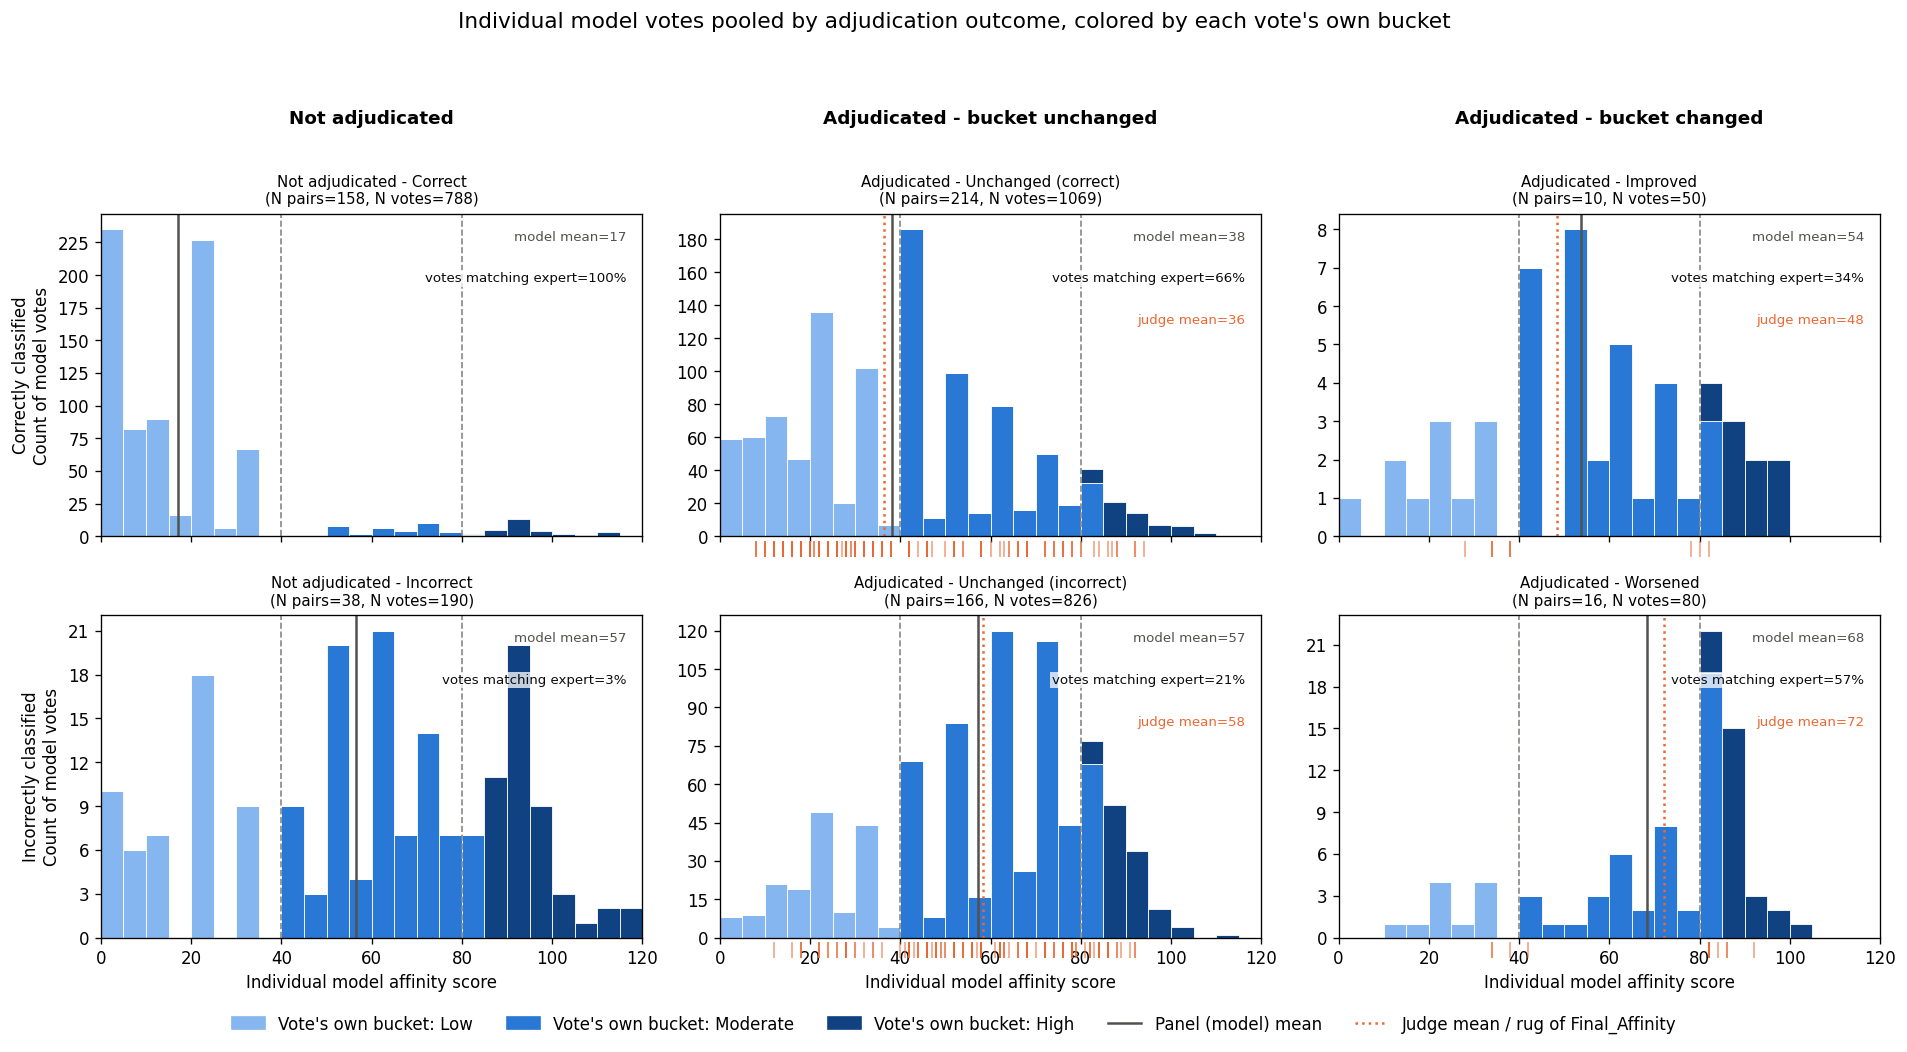

In [ ]:
# Sequential blue ramp (light -> dark) encodes the ordinal Low/Moderate/High bucket;
# amber is reserved for the judge's own Final_Affinity, kept visually distinct from the ramp.
LEVEL_COLORS = {"Low": "#86b6ef", "Moderate": "#2a78d6", "High": "#104281"}
JUDGE_COLOR = "#eb6834"
BOUNDARY_COLOR = "#898781"
MEAN_LINE_COLOR = "#52514e"

BINS = np.arange(0, 125, 5)

GRID_LAYOUT = [
    ("Correctly classified", "Not adjudicated - Correct", "Adjudicated - Unchanged (correct)", "Adjudicated - Improved"),
    ("Incorrectly classified", "Not adjudicated - Incorrect", "Adjudicated - Unchanged (incorrect)", "Adjudicated - Worsened"),
]
COLUMN_TITLES = ["Not adjudicated", "Adjudicated - bucket unchanged", "Adjudicated - bucket changed"]


def plot_outcome_panel(ax, group_name):
    group_votes = score_votes[score_votes["outcome_group"] == group_name]
    n_pairs = pair_info[pair_info["outcome_group"] == group_name].shape[0]

    scores_by_level = [
        group_votes.loc[group_votes["vote_level"] == level, "LLM_Affinity"]
        for level in LABEL_ORDER
    ]
    ax.hist(
        scores_by_level,
        bins=BINS,
        stacked=True,
        color=[LEVEL_COLORS[level] for level in LABEL_ORDER],
        edgecolor="white",
        linewidth=0.5,
    )

    for boundary in (40, 80):
        ax.axvline(boundary, color=BOUNDARY_COLOR, linestyle="--", linewidth=1)

    panel_mean = group_votes["LLM_Affinity"].mean()
    ax.axvline(panel_mean, color=MEAN_LINE_COLOR, linewidth=1.5)
    pct_votes_correct = 100 * group_votes["vote_matches_expert"].mean() if len(group_votes) else float("nan")
    stat_lines = [f"model mean={panel_mean:.0f}", f"votes matching expert={pct_votes_correct:.0f}%"]
    stat_colors = [MEAN_LINE_COLOR, "#0b0b0b"]

    is_adjudicated = group_votes["was_adjudicated"].any() if len(group_votes) else False
    if is_adjudicated:
        judge_values = pair_info.loc[pair_info["outcome_group"] == group_name, "Final_Affinity"]
        y0, y1 = ax.get_ylim()
        rug_y = -0.04 * y1
        ax.plot(judge_values, np.full(len(judge_values), rug_y), "|", color=JUDGE_COLOR, markersize=10, alpha=0.6, clip_on=False)
        judge_mean = judge_values.mean()
        ax.axvline(judge_mean, color=JUDGE_COLOR, linestyle=":", linewidth=1.5)
        stat_lines.append(f"judge mean={judge_mean:.0f}")
        stat_colors.append(JUDGE_COLOR)
        ax.set_ylim(y0, y1)

    # A fixed corner stat box (rather than labels anchored to the mean lines) avoids overlap
    # when the model mean and judge mean happen to sit close together on the x-axis.
    for i, (line, color) in enumerate(zip(stat_lines, stat_colors)):
        ax.text(
            0.97, 0.95 - 0.13 * i, line, transform=ax.transAxes,
            color=color, fontsize=8, ha="right", va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1),
        )

    ax.set_title(f"{group_name}\n(N pairs={n_pairs}, N votes={len(group_votes)})", fontsize=9)
    ax.set_xlim(0, 120)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))


fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for row_idx, (row_label, *group_names) in enumerate(GRID_LAYOUT):
    for col_idx, group_name in enumerate(group_names):
        plot_outcome_panel(axes[row_idx, col_idx], group_name)
    axes[row_idx, 0].set_ylabel(f"{row_label}\nCount of model votes")

for col_idx, title in enumerate(COLUMN_TITLES):
    axes[0, col_idx].annotate(
        title, xy=(0.5, 1.28), xycoords="axes fraction", ha="center", fontsize=11, fontweight="bold",
    )

for ax in axes[-1, :]:
    ax.set_xlabel("Individual model affinity score")

level_handles = [plt.Rectangle((0, 0), 1, 1, color=LEVEL_COLORS[level]) for level in LABEL_ORDER]
judge_handles = [
    plt.Line2D([0], [0], color=MEAN_LINE_COLOR, linewidth=1.5, label="Panel (model) mean"),
    plt.Line2D([0], [0], color=JUDGE_COLOR, linestyle=":", linewidth=1.5, label="Judge mean / rug of Final_Affinity"),
]
fig.legend(
    level_handles + judge_handles,
    [f"Vote's own bucket: {level}" for level in LABEL_ORDER] + [h.get_label() for h in judge_handles],
    loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), frameon=False,
)

fig.suptitle("Individual model votes pooled by adjudication outcome, colored by each vote's own bucket", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()

**Reading the grid, now that color and position agree:**

- **Not adjudicated - Correct**: 100% of votes match the expert — genuine unanimous agreement,
  which is why no judge was ever triggered.
- **Not adjudicated - Incorrect**: only 7% of votes match the expert. The panel was *unanimously
  wrong*, not divided — and because the adjudication trigger fires on cross-model disagreement, a
  confident-but-wrong consensus like this never reaches the judge at all. That's a blind spot the
  worsened/improved framing doesn't cover: 38 pairs are wrong and no judge ever got a chance to fix
  them.
- **Adjudicated, unchanged**: 78% of votes already matched the expert where the outcome stayed
  correct, vs. 23% where it stayed incorrect — the judge is inheriting the panel's accuracy here,
  not adding to it (the gray "model mean" and amber "judge mean" lines sit almost on top of each
  other in both panels).
- **Improved**: only 48% of individual votes matched the expert, i.e. the correct signal was
  genuinely a minority view that the raw mean buried — and the judge surfaced it.
- **Worsened**: 54% of votes matched the expert — a plurality of individual models were *right* —
  and the judge still picked the wrong bucket for every one of these 16 pairs. Visually, a
  moderate-colored (mid-blue) cluster sits just below a high-colored (dark-blue) cluster that
  straddles the 80-point line, and the amber rug of `Final_Affinity` is bimodal (a small group in
  the high-30s/low-40s, a much larger group at 82-92) — the judge is resolving genuine near-boundary
  splits, and resolving them upward more often than the underlying vote counts justify.

So the original claim holds, but more precisely than first stated: it isn't that adjudication is
broadly harmful, or that it ignores hedged reasoning in general — it's specifically that when votes
split close to the 80-point boundary, the judge tips toward High more often than the vote counts
support. The *bigger* accuracy gap in this run, though, is the 38 unanimously-wrong, never-adjudicated
pairs, which no prompt change to the adjudicator will touch since they never reach it.